In [ ]:
import numpy as np
import tensorflow as tf

###Perceptron

In [9]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
import matplotlib.pyplot as plt

In [ ]:
iris = load_iris()
X = iris.data[:, (2, 3)] # petal length, petal width
y = (iris.target == 0).astype(int) # Iris Setosa ?
per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)
y_pred = per_clf.predict([[2, 0.5]])

In [ ]:
y_pred

array([1])

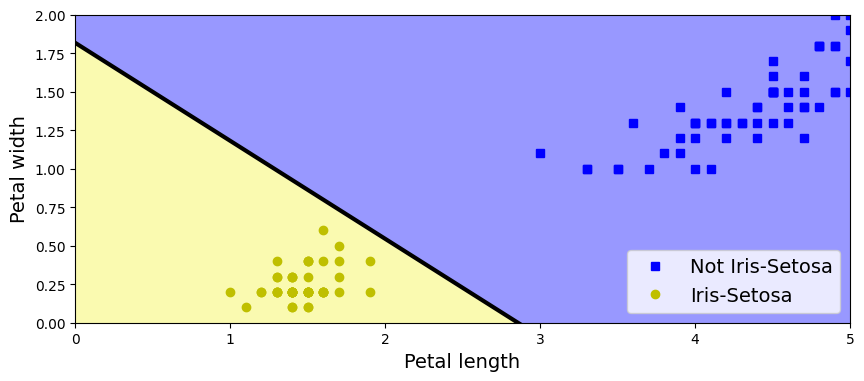

In [11]:
a = -per_clf.coef_[0][0] / per_clf.coef_[0][1]
b = -per_clf.intercept_ / per_clf.coef_[0][1]

axes = [0, 5, 0, 2]

x0, x1 = np.meshgrid(
        np.linspace(axes[0], axes[1], 500).reshape(-1, 1),
        np.linspace(axes[2], axes[3], 200).reshape(-1, 1),
    )
X_new = np.c_[x0.ravel(), x1.ravel()]
y_predict = per_clf.predict(X_new)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y==0, 0], X[y==0, 1], "bs", label="Not Iris-Setosa")
plt.plot(X[y==1, 0], X[y==1, 1], "yo", label="Iris-Setosa")

plt.plot([axes[0], axes[1]], [a * axes[0] + b, a * axes[1] + b], "k-", linewidth=3)
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#9898ff', '#fafab0'])

plt.contourf(x0, x1, zz, cmap=custom_cmap)
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="lower right", fontsize=14)
plt.axis(axes)
plt.show()

In [ ]:
# training mlp with scikit learn
import numpy as np
from sklearn.datasets import load_iris
from sklearn.neural_network import MLPClassifier

# Load iris dataset
iris = load_iris()
X = iris.data[:, [2, 3]]  # Petal length, petal width
y = (iris.target == 0).astype(np.int32)  # Binary: Iris Setosa (1) vs. others (0)

# Initialize and train MLP
mlp_clf = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', solver='adam', random_state=42)
mlp_clf.fit(X, y)

# Predict for a sample input
prediction = mlp_clf.predict([[2.0, 0.5]])
print(f"Prediction for [2.0, 0.5]: {'Iris Setosa' if prediction[0] == 1 else 'Not Iris Setosa'}")

Prediction for [2.0, 0.5]: Not Iris Setosa


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Here, single layer perceptron may be correct rather than mlp, coz its linearly separable problem , mlp might be overfitting.

###Activation Functions

In [12]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def derivative(f, z, eps=0.000001):
    return (f(z + eps) - f(z - eps))/(2 * eps)

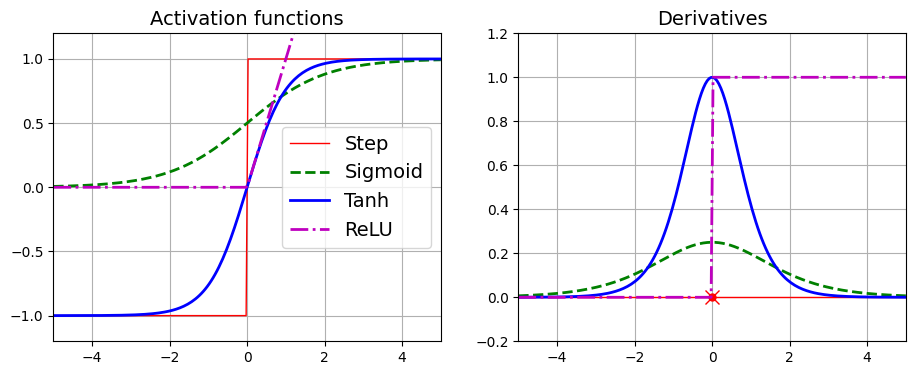

In [13]:
z = np.linspace(-5, 5, 200)

plt.figure(figsize=(11,4))

plt.subplot(121)
plt.plot(z, np.sign(z), "r-", linewidth=1, label="Step")
plt.plot(z, sigmoid(z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, np.tanh(z), "b-", linewidth=2, label="Tanh")
plt.plot(z, relu(z), "m-.", linewidth=2, label="ReLU")
plt.grid(True)
plt.legend(loc="center right", fontsize=14)
plt.title("Activation functions", fontsize=14)
plt.axis([-5, 5, -1.2, 1.2])

plt.subplot(122)
plt.plot(z, derivative(np.sign, z), "r-", linewidth=1, label="Step")
plt.plot(0, 0, "ro", markersize=5)
plt.plot(0, 0, "rx", markersize=10)
plt.plot(z, derivative(sigmoid, z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, derivative(np.tanh, z), "b-", linewidth=2, label="Tanh")
plt.plot(z, derivative(relu, z), "m-.", linewidth=2, label="ReLU")
plt.grid(True)
#plt.legend(loc="center right", fontsize=14)
plt.title("Derivatives", fontsize=14)
plt.axis([-5, 5, -0.2, 1.2])

plt.show()

###MNIST data classification using tensorflow's high-level api

In [15]:
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [16]:
#Load and preprocess MNIST
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_train = X_train.reshape(-1, 784).astype('float32')  # Flatten 28x28 images
X_test = X_test.reshape(-1, 784).astype('float32')
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [18]:
# Build MLP
model = Sequential([
    Dense(300, activation='relu', input_shape=(784,)),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
# Compile and train
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, batch_size=50, epochs=10)  # ~40000 steps

Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8965 - loss: 0.3546
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9749 - loss: 0.0852
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9802 - loss: 0.0613
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9866 - loss: 0.0430
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9902 - loss: 0.0336
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9908 - loss: 0.0301
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9915 - loss: 0.0265
Epoch 8/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9923 - loss: 0.0242
Epoch 9/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9929 - loss: 0.0222
Epoch 10/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9938 - loss: 0.0190


In [20]:
y_pred = model.predict(X_test).argmax(axis=1)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.973
